# Proyecto Final - Machine Learning Carlos Fernando Gonzalez Sarmiento

# Predicción de la intención de compra en sesiones de comercio electrónico mediante Machine Learning

## Mi pregunta o problematica es: ¿Es posible predecir si la sesión de navegación de un usuario terminará en una compra?

Las tiendas virtuales reciben numerosas visitas, pero no todas las sesiones de
navegación terminan en una compra. Poder identificar anticipadamente cuáles
sesiones tienen mayor probabilidad de generar una compra puede ayudar a las
empresas a comprender mejor el comportamiento de sus visitantes y a diseñar
estrategias comerciales más efectivas.

En este proyecto se utilizarán técnicas de aprendizaje supervisado para construir
modelos capaces de clasificar una sesión según si finaliza o no en una compra,
a partir de características relacionadas con la navegación del usuario dentro
del sitio web.

Para ello, se entrenarán y compararán tres modelos de clasificación:
Regresión Logística, K-Nearest Neighbors y Random Forest.

## Objetivo general

Desarrollar y comparar modelos de clasificación que permitan predecir si una
sesión de navegación en una tienda virtual finalizará en una compra, utilizando
información relacionada con el comportamiento del visitante dentro del sitio web.

## Objetivos específicos

- Explorar las características de las sesiones de navegación presentes en el dataset.
- Preparar y transformar los datos para su utilización en modelos de Machine Learning.
- Entrenar modelos de Regresión Logística, KNN y Random Forest.
- Evaluar los modelos mediante métricas apropiadas para un problema de clasificación.
- Identificar e interpretar el modelo con mejor capacidad para predecir las compras.
- Analizar las variables que aportan mayor información a las predicciones.

## Base a utilizar

Link: https://archive.ics.uci.edu/dataset/468/online%20shoppers%20purchasing%20intention%20dataset

## Librerías a usar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df_osi = pd.read_csv(r"C:\Users\piki_\Downloads\online_shoppers_intention.csv")
df_osi.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### Descripción de las variables

**Administrative:** cantidad de páginas administrativas visitadas durante la sesión.

**Administrative_Duration:** tiempo total que el usuario permaneció navegando en páginas administrativas.

**Informational:** cantidad de páginas informativas visitadas durante la sesión.

**Informational_Duration:** tiempo total que el usuario permaneció en páginas informativas.

**ProductRelated:** cantidad de páginas relacionadas con productos que fueron visitadas durante la sesión.

**ProductRelated_Duration:** tiempo total que el usuario permaneció consultando páginas relacionadas con productos.

**BounceRates:** tasa de rebote promedio de las páginas visitadas. Representa la proporción de usuarios que abandonan el sitio sin continuar interactuando.

**ExitRates:** tasa de salida promedio de las páginas visitadas. Indica con qué frecuencia una página fue la última consultada antes de abandonar el sitio.

**PageValues:** valor promedio asignado a las páginas visitadas antes de que se produzca una compra.

**SpecialDay:** cercanía de la sesión a una fecha comercial especial, como el Día de la Madre o San Valentín.

**Month:** mes en el que se realizó la sesión de navegación.

**OperatingSystems:** código que identifica el sistema operativo utilizado por el visitante.

**Browser:** código que identifica el navegador utilizado durante la sesión.

**Region:** código correspondiente a la región desde la cual se realizó la visita.

**TrafficType:** código que representa la fuente o el tipo de tráfico mediante el cual el usuario llegó al sitio web.

**VisitorType:** tipo de visitante, por ejemplo, usuario nuevo, recurrente u otra categoría.

**Weekend:** indica si la sesión se realizó durante un fin de semana.

**Revenue:** variable que se desea predecir. Indica si la sesión terminó en una compra (`True`) o no (`False`).

In [3]:
df_osi.shape

(12330, 18)

La base tiene una dimensión de 12.330 filas y 18 columnas.

In [4]:
df_osi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

Inicialmente en el info podemos visualizar que hay 2 variables booleanas, 7 decimales, 7 enteras y 2 categoricas, parece ser que no hay nulos, sin embargo comprobemoslo por nosotros mismos.

**OperatingSystems, Browser, Region y TrafficType** aunque aparecen como números, realmente son categorías identificadas mediante códigos. No representan cantidades. Por ejemplo, un navegador (browser) con código 4 no es mayor que uno con código 2

In [5]:
df_osi.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

En efecto, no tenemos nulos

Verifiquemos si existen registros duplicados

In [6]:
df_osi.duplicated().sum()

125

En este caso existen 125 registros duplicados.

Sin embargo, el dataset no contiene un identificador único de usuario o de sesión que permita concluir que estos registros corresponden a información duplicada. Además, la documentación del conjunto de datos indica que fue construido procurando que cada sesión perteneciera a un usuario diferente durante el periodo analizado.

Por esta razón, es posible que los registros iguales representen usuarios distintos con comportamientos de navegación similares. En un escenario real, esta situación debería ser validada con el propietario o responsable de los datos.

Debido a que no existe evidencia suficiente para considerar estas filas como errores de duplicación, se decidió conservarlas en el análisis.

In [7]:
df_osi.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


Aca podemos ver las descriptivas de nuestra base.

In [8]:
df_osi.describe(include=["object", "bool"]).T

,count,unique,top,freq
Month,12330,10,May,3364
VisitorType,12330,3,Returning_Visitor,10551
Weekend,12330,2,False,9462
Revenue,12330,2,False,10422


Acá podemos ver las descriptivas de las variables boleanas y categoricas.

In [9]:
df_osi["Revenue"].value_counts()

False    10422
True      1908
Name: Revenue, dtype: int64

Nuestra variable objetivo tiene 15,5% de resultado de terminación en compra y 84,5% de no termino en compra.

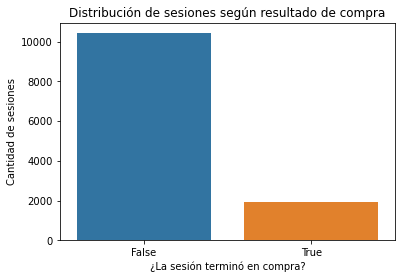

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_osi,
    x="Revenue"
)

plt.title("Distribución de sesiones según resultado de compra")
plt.xlabel("¿La sesión terminó en compra?")
plt.ylabel("Cantidad de sesiones")

plt.show()

En la gráfica se evidencia un desbalance entre las dos categorías, ya que las sesiones sin compra representan la mayoría de los registros.

Por esta razón, durante la evaluación de los modelos no se tendrá en cuenta únicamente el Accuracy. También será necesario analizar métricas como Precision, Recall, F1-score y las matrices de confusión, especialmente para evaluar la capacidad de los modelos de identificar las sesiones que realmente terminan en compra.

## Análisis exploratorio de datos

 Para el EDA que vamos a hacer visualizaciones basandonos en la siguiente pregunta:
 **¿Qué características diferencian a las sesiones que terminan en compra de aquellas que no terminan en compra?**

Haré una copia de la base para hacer algunos cambios en la base y no dañar los datos con el fin de que el EDA pueda ser lo mas entendible posible.

In [11]:
df_eda = df_osi.copy()

# Etiqueta en español para las visualizaciones
df_eda["Compra"] = df_eda["Revenue"].map({
    True: "Sí compró",
    False: "No compró"
})

df_eda[["Revenue", "Compra"]].head()

,Revenue,Compra
0,False,No compró
1,False,No compró
2,False,No compró
3,False,No compró
4,False,No compró


Vamos a concentarnos en algunas variables númericas clave para hacer comparativas

In [12]:
variables_numericas_clave = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

In [13]:
resumen_por_compra = (
    df_eda
    .groupby("Compra")[variables_numericas_clave]
    .median()
    .T
    .round(3)
)

resumen_por_compra

Compra,No compró,Sí compró
Administrative,0.000,2.000
Administrative_Duration,0.000,52.367
Informational,0.000,0.000
Informational_Duration,0.000,0.000
ProductRelated,16.000,29.000
ProductRelated_Duration,510.190,1109.906
BounceRates,0.004,0.000
ExitRates,0.029,0.016
PageValues,0.000,16.758
SpecialDay,0.000,0.000


Se compararon las medianas de las principales variables numéricas entre las sesiones que terminaron en compra y aquellas que no finalizaron en una transacción, se usó la mediana puesto que la mediana es indiferente a los valores extremos altos o bajos.

Haciendo referencia a el caso de sesiones que si terminaron en compra, se encontró que:
* Visitaron una mediana de 29 páginas de productos, frente a 16 en las sesiones sin compra.
* Permanecieron aproximadamente 1.110 segundos en páginas de productos, frente a 510 segundos.
* También consultaron más páginas administrativas.
* Presentaron menores tasas de rebote y de salida.
* PageValues tuvo una mediana de 16,758 en las sesiones con compra y de 0 en las sesiones sin compra.

Esto quiere decir que quienes compran suelen explorar más productos, permanecer más tiempo navegando y abandonar menos rápidamente el sitio.

In [14]:
analisis_visitante = (
    df_eda
    .groupby("VisitorType")
    .agg(
        Sesiones=("Revenue", "size"),
        Compras=("Revenue", "sum"),
        Tasa_compra=("Revenue", "mean")
    )
    .reset_index()
)

analisis_visitante["Tasa_compra"] = (
    analisis_visitante["Tasa_compra"] * 100
).round(2)

analisis_visitante

,VisitorType,Sesiones,Compras,Tasa_compra
0,New_Visitor,1694,422,24.91
1,Other,85,16,18.82
2,Returning_Visitor,10551,1470,13.93


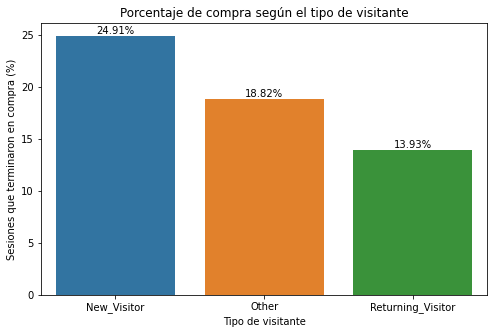

In [15]:
plt.figure(figsize=(8, 5))

grafica_visitante = sns.barplot(
    data=analisis_visitante,
    x="VisitorType",
    y="Tasa_compra"
)

plt.title("Porcentaje de compra según el tipo de visitante")
plt.xlabel("Tipo de visitante")
plt.ylabel("Sesiones que terminaron en compra (%)")

for barra in grafica_visitante.patches:
    altura = barra.get_height()

    grafica_visitante.annotate(
        f"{altura:.2f}%",
        (barra.get_x() + barra.get_width() / 2, altura),
        ha="center",
        va="bottom"
    )

plt.show()

Acá se evidencia que hay mayor tasa de compra en los nuevos visitantes.

Sin embargo, los visitantes recurrentes representan la gran mayoría de las sesiones y también generan la mayor cantidad total de compras.

In [16]:
analisis_mes = (
    df_eda
    .groupby("Month")
    .agg(
        Sesiones=("Revenue", "size"),
        Compras=("Revenue", "sum"),
        Tasa_compra=("Revenue", "mean")
    )
    .reset_index()
)

analisis_mes["Tasa_compra"] = (
    analisis_mes["Tasa_compra"] * 100
).round(2)

In [17]:
orden_meses = [
    "Feb", "Mar", "May", "June", "Jul",
    "Aug", "Sep", "Oct", "Nov", "Dec"
]

analisis_mes["Month"] = pd.Categorical(
    analisis_mes["Month"],
    categories=orden_meses,
    ordered=True
)

analisis_mes = analisis_mes.sort_values("Month")

analisis_mes

,Month,Sesiones,Compras,Tasa_compra
2,Feb,184,3,1.63
5,Mar,1907,192,10.07
6,May,3364,365,10.85
4,June,288,29,10.07
3,Jul,432,66,15.28
0,Aug,433,76,17.55
9,Sep,448,86,19.20
8,Oct,549,115,20.95
7,Nov,2998,760,25.35
1,Dec,1727,216,12.51


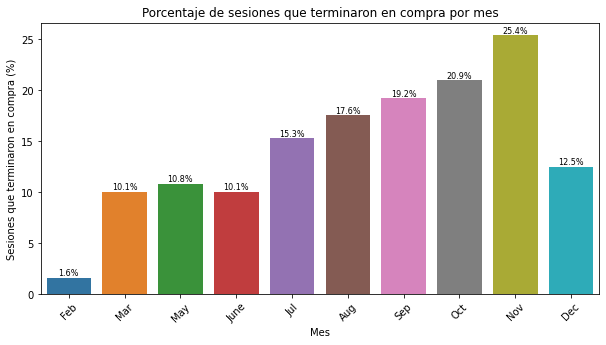

In [18]:
plt.figure(figsize=(10, 5))

grafica_mes = sns.barplot(
    data=analisis_mes,
    x="Month",
    y="Tasa_compra"
)

plt.title("Porcentaje de sesiones que terminaron en compra por mes")
plt.xlabel("Mes")
plt.ylabel("Sesiones que terminaron en compra (%)")
plt.xticks(rotation=45)

for barra in grafica_mes.patches:
    altura = barra.get_height()

    grafica_mes.annotate(
        f"{altura:.1f}%",
        (barra.get_x() + barra.get_width() / 2, altura),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.show()

Por lo que nos está proporcionando esta gráfica podemos observar que los meses en los que las sesiones tienen mas terminación en compras son los meses de noviembre con el 25,4%, le sigue octubre con el 20,9% y en tercer lugar septiembre con 19,2%.

In [19]:
analisis_weekend = (
    df_eda
    .groupby("Weekend")
    .agg(
        Sesiones=("Revenue", "size"),
        Compras=("Revenue", "sum"),
        Tasa_compra=("Revenue", "mean")
    )
    .reset_index()
)

analisis_weekend["Tasa_compra"] = (
    analisis_weekend["Tasa_compra"] * 100
).round(2)

analisis_weekend["Weekend"] = analisis_weekend["Weekend"].map({
    False: "Entre semana",
    True: "Fin de semana"
})

analisis_weekend

,Weekend,Sesiones,Compras,Tasa_compra
0,Entre semana,9462,1409,14.89
1,Fin de semana,2868,499,17.40


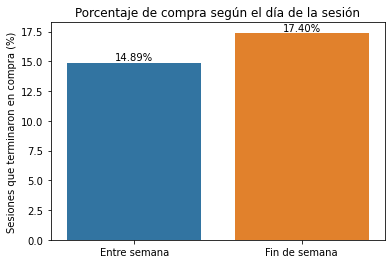

In [20]:
plt.figure(figsize=(6, 4))

grafica_weekend = sns.barplot(
    data=analisis_weekend,
    x="Weekend",
    y="Tasa_compra"
)

plt.title("Porcentaje de compra según el día de la sesión")
plt.xlabel("")
plt.ylabel("Sesiones que terminaron en compra (%)")

for barra in grafica_weekend.patches:
    altura = barra.get_height()

    grafica_weekend.annotate(
        f"{altura:.2f}%",
        (barra.get_x() + barra.get_width() / 2, altura),
        ha="center",
        va="bottom"
    )

plt.show()

Vemos que en la comparativa de las sesiones que fueron entre semana vs las sesiones que fueron en un fin de semana hubo mayor tasa de sesiones los fines de semana que terminaron en compras.

In [21]:
variables_correlacion = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

In [22]:
df_correlacion = df_eda[variables_correlacion + ["Revenue"]].copy()

df_correlacion["Revenue"] = (
    df_correlacion["Revenue"]
    .astype(int)
)

In [23]:
correlaciones_revenue = (
    df_correlacion
    .corr()["Revenue"]
    .drop("Revenue")
    .sort_values()
)

correlaciones_revenue

ExitRates                 -0.207071
BounceRates               -0.150673
SpecialDay                -0.082305
Informational_Duration     0.070345
Administrative_Duration    0.093587
Informational              0.095200
Administrative             0.138917
ProductRelated_Duration    0.152373
ProductRelated             0.158538
PageValues                 0.492569
Name: Revenue, dtype: float64

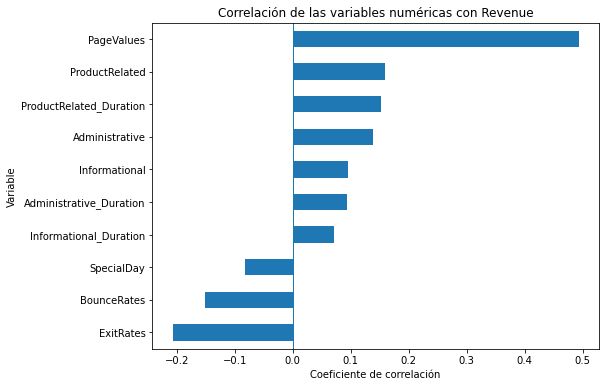

In [24]:
plt.figure(figsize=(8, 6))

correlaciones_revenue.plot(
    kind="barh"
)

plt.title("Correlación de las variables numéricas con Revenue")
plt.xlabel("Coeficiente de correlación")
plt.ylabel("Variable")
plt.axvline(0, linewidth=1)

plt.show()

La correlación permite identificar relaciones lineales entre las variables numéricas y el resultado de compra. Sin embargo, una correlación no demuestra que una variable cause directamente una compra.

`PageValues` presentó la mayor correlación positiva con `Revenue`, con un valor
de 0,493. Esto indica que las sesiones con valores más altos en esta variable
tendieron a finalizar en compra con mayor frecuencia.

La cantidad de páginas relacionadas con productos y el tiempo dedicado a estas
páginas también presentaron relaciones positivas con la compra, aunque de una
magnitud menor.

Por otra parte, `ExitRates` y `BounceRates` mostraron correlaciones negativas.
Esto significa que las sesiones con mayores tasas de salida o rebote tendieron
a terminar con menor frecuencia en una compra.

Las demás variables presentaron correlaciones débiles. Sin embargo, esto no
significa que deban eliminarse automáticamente, ya que la correlación solamente
mide relaciones lineales y los modelos pueden encontrar interacciones o
relaciones más complejas entre varias características.

### Conclusiones del análisis exploratorio

El análisis exploratorio permitió identificar diferencias claras entre las
sesiones que terminaron en compra y aquellas que no generaron una transacción.

Las sesiones con compra presentaron una mayor cantidad de páginas de productos
visitadas, un mayor tiempo de navegación en estas páginas y menores tasas de
rebote y salida. Esto sugiere que una interacción más profunda con el contenido
del sitio se encuentra relacionada con una mayor intención de compra.

También se observaron diferencias según el tipo de visitante. Los visitantes
nuevos presentaron la tasa de compra más alta, aunque los visitantes recurrentes
generaron la mayor cantidad total de compras debido a que representan la mayoría
de las sesiones.

En cuanto al comportamiento mensual, noviembre presentó la mayor tasa y una
cantidad elevada de compras. También se observaron tasas relativamente altas
durante septiembre y octubre. Sin embargo, las diferencias en la cantidad de
sesiones por mes deben considerarse al interpretar estos resultados.

Las sesiones realizadas durante el fin de semana presentaron una tasa de compra
ligeramente superior a la de las sesiones realizadas entre semana.

Finalmente, `PageValues` fue la variable numérica con mayor relación lineal con
la compra. Por su parte, `ExitRates` y `BounceRates` presentaron relaciones
negativas, lo que indica que mayores niveles de abandono se encuentran asociados
con una menor frecuencia de compra.

Estos resultados no demuestran relaciones causales, pero permiten identificar
patrones relevantes que podrán ser aprovechados durante la construcción de los
modelos de clasificación.

## Preprocesamiento de datos

In [25]:
df_osim=df_osi.copy()
df_osim

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [26]:
df_osim["Revenue"] = df_osim["Revenue"].astype(int) #Volvemos la variable onjetivo en entero

La variable objetivo `Revenue` se transformó a valores numéricos, asignando
el valor 1 a las sesiones que finalizaron en una compra y el valor 0 a las
sesiones que no generaron una transacción.

In [27]:
columnas_categoricas = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType"
]

In [28]:
df_osim["Weekend"] = df_osim["Weekend"].astype(int) # Convertimos fin de semana en entero para que quede en 1 y 0

df_osim["Weekend"].value_counts()

0    9462
1    2868
Name: Weekend, dtype: int64

In [29]:
df_osim = pd.get_dummies(
    df_osim,
    columns=columnas_categoricas,
    drop_first=True,
    dtype=int
)

df_osim.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1


In [30]:
drop_first=True

Las variables categóricas se transformaron mediante One-Hot Encoding.
Este procedimiento crea columnas binarias que permiten representar cada
categoría mediante valores numéricos.

Se utilizó `drop_first=True` para eliminar una categoría de referencia por
cada variable y evitar información redundante entre las nuevas columnas.

In [31]:
df_osim.shape#Con estas dimensiones quedamos

(12330, 69)

In [32]:
df_osim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 69 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  Weekend                        12330 non-null  int32  
 11  Revenue                        12330 non-null  int32  
 12  Month_Dec                      12330 non-null 

In [33]:
# Variables predictoras
X = df_osim.drop("Revenue", axis=1)

# Variable objetivo
y = df_osim["Revenue"]

Se separo la variable `Revenue` que es la variable objetivo y se dejo como la variable `y`

Las demás columnas conforman el conjunto de características predictoras,
representado mediante `X`

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Los datos se dividieron utilizando el 80 % para entrenamiento y el 20 %
para prueba.

Se utilizó `random_state=42` para garantizar que la división pueda
quedar fija y `stratify=y` para conservar una proporción similar de
sesiones con compra y sin compra en ambos conjuntos.

Ahora escalaremos algunas columnas para la regresión logistica

In [35]:
columnas_numericas = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

Realizamos copias para escalar

In [36]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [37]:
scaler = StandardScaler()

X_train_scaled[columnas_numericas] = scaler.fit_transform(
    X_train[columnas_numericas]
)

X_test_scaled[columnas_numericas] = scaler.transform(
    X_test[columnas_numericas]
)

## Entrenamiento de los modelos

Se entrenaron tres algoritmos de clasificación: Regresión Logística, KNN y
Random Forest. Debido al desbalance de la variable objetivo, la comparación
se realizará mediante Accuracy, Precision, Recall, F1-score.

La Regresión Logística y KNN utilizan los datos escalados, mientras que
Random Forest utiliza los datos sin escalar.

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [39]:
# Regresión Logística
modelo_logistico = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

modelo_logistico.fit(X_train_scaled, y_train)

y_pred_logistico = modelo_logistico.predict(X_test_scaled)
y_prob_logistico = modelo_logistico.predict_proba(X_test_scaled)[:, 1]


# KNN
modelo_knn = KNeighborsClassifier(n_neighbors=5)

modelo_knn.fit(X_train_scaled, y_train)

y_pred_knn = modelo_knn.predict(X_test_scaled)
y_prob_knn = modelo_knn.predict_proba(X_test_scaled)[:, 1]


# Random Forest
modelo_random_forest = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

modelo_random_forest.fit(X_train, y_train)

y_pred_random_forest = modelo_random_forest.predict(X_test)
y_prob_random_forest = modelo_random_forest.predict_proba(X_test)[:, 1]

In [40]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "KNN",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistico),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_random_forest)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistico, zero_division=0),
        precision_score(y_test, y_pred_knn, zero_division=0),
        precision_score(y_test, y_pred_random_forest, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistico, zero_division=0),
        recall_score(y_test, y_pred_knn, zero_division=0),
        recall_score(y_test, y_pred_random_forest, zero_division=0)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_logistico, zero_division=0),
        f1_score(y_test, y_pred_knn, zero_division=0),
        f1_score(y_test, y_pred_random_forest, zero_division=0)
    ]
}).round(4)

resultados.sort_values("F1-score", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1-score
2,Random Forest,0.8982,0.7569,0.5052,0.6060
0,Regresión Logística,0.8418,0.4931,0.7435,0.5929
1,KNN,0.8666,0.6157,0.3691,0.4615


In [41]:
predicciones = {
    "Regresión Logística": y_pred_logistico,
    "KNN": y_pred_knn,
    "Random Forest": y_pred_random_forest
}

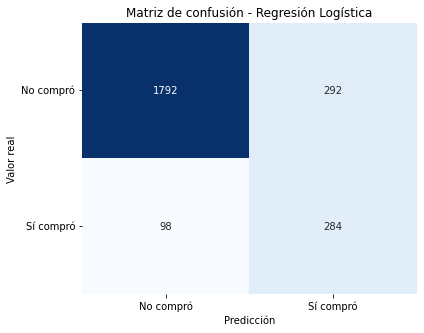

In [42]:
matriz_logistico = confusion_matrix(y_test, y_pred_logistico)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_logistico,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0.5, 1.5], ["No compró", "Sí compró"])
plt.yticks([0.5, 1.5], ["No compró", "Sí compró"], rotation=0)

plt.show()

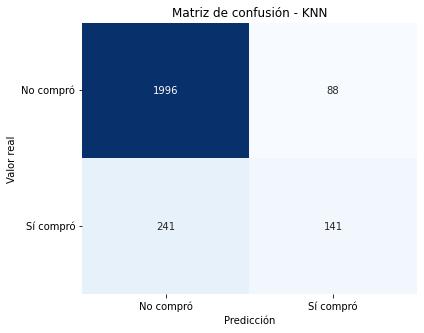

In [43]:
matriz_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Matriz de confusión - KNN")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0.5, 1.5], ["No compró", "Sí compró"])
plt.yticks([0.5, 1.5], ["No compró", "Sí compró"], rotation=0)

plt.show()

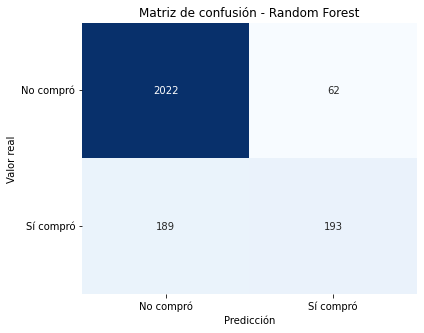

In [44]:
matriz_random_forest = confusion_matrix(
    y_test,
    y_pred_random_forest
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_random_forest,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0.5, 1.5], ["No compró", "Sí compró"])
plt.yticks([0.5, 1.5], ["No compró", "Sí compró"], rotation=0)

plt.show()

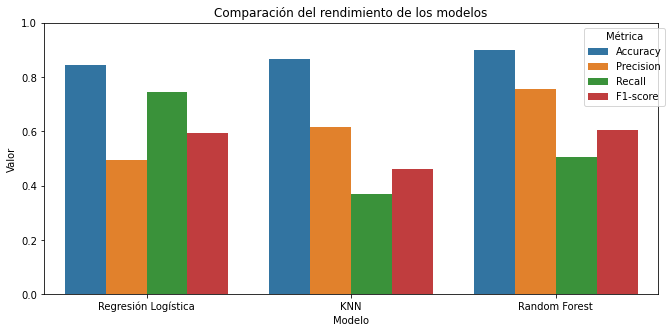

In [45]:
resultados_grafica = resultados.melt(
    id_vars="Modelo",
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=resultados_grafica,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.title("Comparación del rendimiento de los modelos")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.legend(title="Métrica", bbox_to_anchor=(1.02, 1))

plt.show()

En los rendimientos de los modelos 

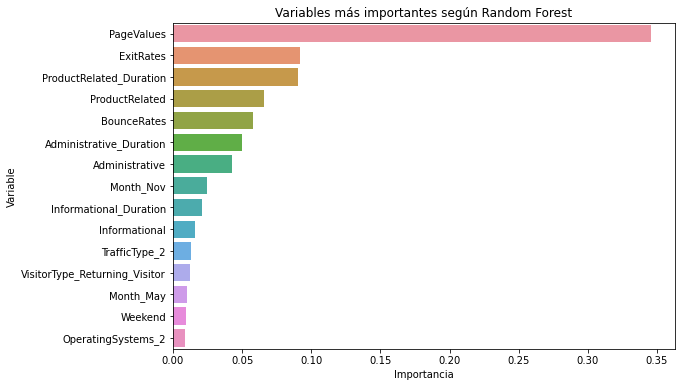

,Variable,Importancia
8,PageValues,0.345814
7,ExitRates,0.091830
5,ProductRelated_Duration,0.090066
4,ProductRelated,0.065764
6,BounceRates,0.058057
1,Administrative_Duration,0.049674
0,Administrative,0.042667
17,Month_Nov,0.024375
3,Informational_Duration,0.021261
2,Informational,0.015962


In [46]:
importancia_variables = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": modelo_random_forest.feature_importances_
})

importancia_variables = (
    importancia_variables
    .sort_values("Importancia", ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=importancia_variables,
    x="Importancia",
    y="Variable"
)

plt.title("Variables más importantes según Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.show()

importancia_variables

Podemos evidenciar que las variables mas importantes son "PageValues", Exitrates, ProductRelated_Duration

In [47]:
resultados.sort_values("F1-score", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1-score
2,Random Forest,0.8982,0.7569,0.5052,0.6060
0,Regresión Logística,0.8418,0.4931,0.7435,0.5929
1,KNN,0.8666,0.6157,0.3691,0.4615


## Comparación y selección del mejor modelo

Al comparar los tres modelos, **Random Forest** obtuvo el mejor desempeño general.
Alcanzó un Accuracy de 89,82 %, una Precision de 75,69 % y el mayor F1-score,
con un valor de 60,60 %.

La matriz de confusión muestra que **Random Forest** identificó correctamente 193
sesiones que finalizaron en compra y solamente clasificó 62 sesiones sin compra
como si hubieran terminado en una transacción. Sin embargo, dejó sin identificar
189 compras reales, lo que se refleja en un Recall de 50,52 %.

La **Regresión Logística** obtuvo el mejor Recall, con un 74,35 %, identificando
correctamente 284 de las 382 compras reales del conjunto de prueba. No obstante,
también generó 292 falsos positivos, por lo que su Precision fue menor, con un
49,31 %.

**KNN** presentó el desempeño más bajo. Aunque obtuvo un Accuracy de 86,66 %, solo
identificó correctamente 141 compras y dejó sin detectar 241, obteniendo el
Recall y el F1-score más bajos de los tres modelos.

Teniendo en cuenta el equilibrio entre las métricas evaluadas, se seleccionó
**Random Forest** como el mejor modelo. Este algoritmo obtuvo el mayor F1-score,
la mejor Precision y el mayor porcentaje general de predicciones correctas.

Sin embargo, si el objetivo principal de la empresa fuera **identificar la mayor
cantidad posible de compradores**, aunque se generaran más falsas alertas, la
**Regresión Logística podría ser una alternativa** debido a su mayor Recall.

## Decisión final

**Modelo seleccionado: Random Forest**, porque presenta el mejor rendimiento general.

La **Regresión Logística** queda como **alternativa** cuando sea más importante no dejar escapar compradores potenciales. El siguiente paso es mostrar la importancia de las variables de Random Forest y cerrar con las conclusiones finales.